# EXIM Bank Export Credit Data — Exploratory Data Analysis & ML-Readiness Prep
**Dataset:** `data-gov_fy26-q2.csv` — U.S. Export-Import Bank (EXIM) authorized transactions (FY2007–FY2026 Q2)
**Prepared by:** Data Analyst (hand-off to ML Engineering team)
**Purpose:** Understand the data, clean it, engineer candidate features, and document everything an ML engineer
needs to know before building a model on this data (e.g. predicting `Decision`, predicting `Outstanding Exposure Amount`,
or risk/default-proxy modeling).

This notebook is organized as:
1. Load & first look
2. Data quality audit (missing values, duplicates, types)
3. Cleaning
4. Univariate analysis
5. Bivariate / relationship analysis
6. Outlier detection
7. Feature engineering for ML
8. Export of ML-ready dataset
9. Final conclusions (see also `analysis_report.txt`)


## 1. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display options for easier inspection
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')

# NOTE: encoding='utf-8-sig' strips the BOM (\ufeff) that Excel-exported
# government CSVs commonly have on the first column name.
RAW_PATH = "data-gov_fy26-q2.csv"
df = pd.read_csv(RAW_PATH, encoding='utf-8-sig', low_memory=False)

print("Shape:", df.shape)
df.head()


Shape: (52734, 34)


,Fiscal Year,Unique Identifier,Deal Number,Decision,Decision Date,Effective Date,Expiration Date,Brokered,Deal Cancelled,Country,Program,Policy Type,Decision Authority,Primary Export Product NAICS/SIC code,Product Description,Term,Primary Applicant,Primary Lender,Primary Exporter,Primary Exporter City,Primary Exporter State Code,Primary Exporter State Name,Primary Borrower,Primary Source of Repayment (PSOR),Working Capital Delegated Authority,Approved/Declined Amount,Disbursed/Shipped Amount,Undisbursed Exposure Amount,Outstanding Exposure Amount,Small Business Authorized Amount,Woman Owned Authorized Amount,Minority Owned Authorized Amount,Loan Interest Rate,Multiyear Working Capital Extension
0,2007,08003048XA0002,AP003048AA,Approved,11/29/2006,NaN,12/15/2011,No,No,Private Export Funding Corp.,Guarantee,NaN,Board,NaN,NaN,Long Term,Private Export Funding Corporation,Private Export Funding Corporation,NaN,NaN,NaN,NaN,Private Export Funding Corporation,Various Us Companies,NaN,24500000.0,24500000.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
1,2007,08003048XA0003,AP003048AA,Approved,11/29/2006,11/29/2006,12/15/2016,No,No,Private Export Funding Corp.,Guarantee,NaN,Board,NaN,NaN,Long Term,Private Export Funding Corporation,Private Export Funding Corporation,NaN,NaN,NaN,NaN,Private Export Funding Corporation,Various Us Companies,NaN,50000000.0,50000000.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2,2007,08003048XA0004,AP003048AA,Approved,8/16/2007,8/16/2007,9/15/2017,No,No,Private Export Funding Corp.,Guarantee,NaN,Board,NaN,NaN,Long Term,Private Export Funding Corporation,Private Export Funding Corporation,NaN,NaN,NaN,NaN,Private Export Funding Corporation,Various Us Companies,NaN,136250000.0,136250000.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
3,2007,08064737XM0001,AP064737XM,Approved,9/21/2007,9/21/2007,7/31/2008,No,No,United States,Working Capital,NaN,Individual Delegated Authority,5088,Transportation Equipment and Supplies - Except...,Short Term,Bank Of America N.A.,Bank Of America N.A.,American General Supplies,Gaithersburg,MD,Maryland,American General Supplies,American General Supplies,Yes,2700000.0,2700000.0,0.0,0.0,2700000.0,0.0,2700000.0,NaN,NaN
4,2007,08069888XG0003,AP069888XG,Approved,11/24/2006,11/24/2006,1/1/2007,No,No,United States,Working Capital,NaN,Individual Delegated Authority,3546,Power-Driven Handtools,Short Term,Ups Capital Business Credit,Ups Capital Business Credit,Kell-Strom Tool Co Inc,Wethersfield,CT,Connecticut,Kell-Strom Tool Co Inc,Kell-Strom Tool Co Inc,Yes,233307.9,233307.9,0.0,0.0,0.0,0.0,0.0,NaN,NaN


In [2]:
# Column names often carry trailing/leading whitespace in gov exports
# (e.g. 'Brokered ' has a trailing space). Fix this immediately so we
# never have to remember it again downstream.
df.columns = [c.strip() for c in df.columns]
print(df.columns.tolist())


['Fiscal Year', 'Unique Identifier', 'Deal Number', 'Decision', 'Decision Date', 'Effective Date', 'Expiration Date', 'Brokered', 'Deal Cancelled', 'Country', 'Program', 'Policy Type', 'Decision Authority', 'Primary Export Product NAICS/SIC code', 'Product Description', 'Term', 'Primary Applicant', 'Primary Lender', 'Primary Exporter', 'Primary Exporter City', 'Primary Exporter State Code', 'Primary Exporter State Name', 'Primary Borrower', 'Primary Source of Repayment (PSOR)', 'Working Capital Delegated Authority', 'Approved/Declined Amount', 'Disbursed/Shipped Amount', 'Undisbursed Exposure Amount', 'Outstanding Exposure Amount', 'Small Business Authorized Amount', 'Woman Owned Authorized Amount', 'Minority Owned Authorized Amount', 'Loan Interest Rate', 'Multiyear Working Capital Extension']


## 2. Data Quality Audit

Before touching the data we quantify: how big is it, what types are present, how much is missing,
are there duplicate records, and do the numeric columns contain impossible values (negatives, etc).
This step is what tells an ML engineer how much trust to place in each column.


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52734 entries, 0 to 52733
Data columns (total 34 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Fiscal Year                            52734 non-null  int64  
 1   Unique Identifier                      52734 non-null  object 
 2   Deal Number                            52727 non-null  object 
 3   Decision                               52734 non-null  object 
 4   Decision Date                          52734 non-null  object 
 5   Effective Date                         51483 non-null  object 
 6   Expiration Date                        52043 non-null  object 
 7   Brokered                               52734 non-null  object 
 8   Deal Cancelled                         52734 non-null  object 
 9   Country                                52734 non-null  object 
 10  Program                                52734 non-null  object 
 11  Po

In [4]:
# Missing value audit — count + percentage, sorted descending.
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_report = missing_report[missing_report['missing_count'] > 0]
missing_report


,missing_count,missing_pct
Multiyear Working Capital Extension,52483,99.52
Loan Interest Rate,52354,99.28
Working Capital Delegated Authority,46598,88.36
Primary Lender,31029,58.84
Policy Type,9258,17.56
Primary Exporter City,1711,3.24
Primary Exporter State Code,1711,3.24
Primary Exporter State Name,1711,3.24
Primary Export Product NAICS/SIC code,1517,2.88
Product Description,1517,2.88


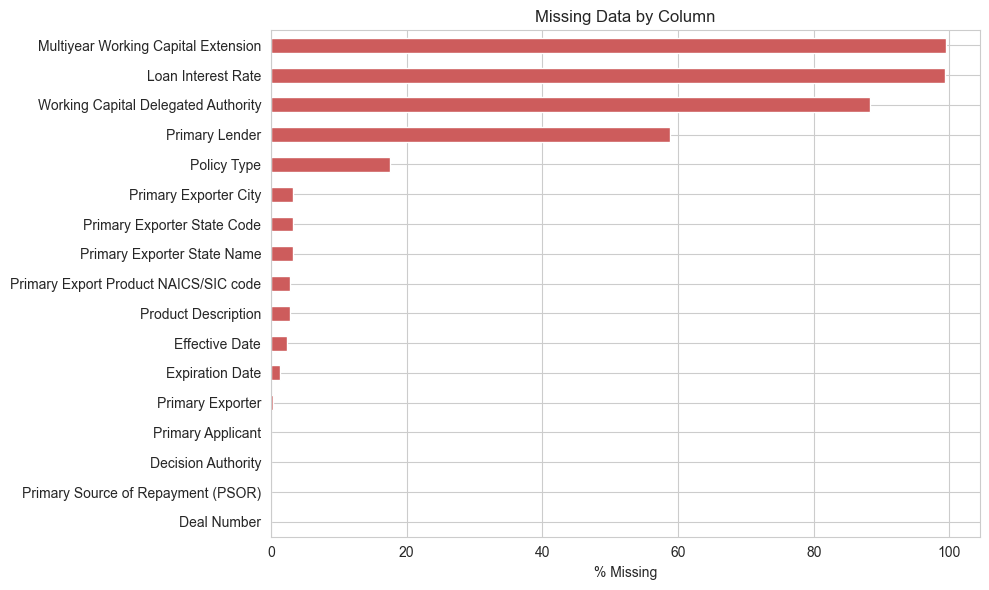

In [5]:
# Visualize missingness so the pattern is obvious at a glance.
fig, ax = plt.subplots(figsize=(10, 6))
missing_report['missing_pct'].sort_values().plot(kind='barh', ax=ax, color='indianred')
ax.set_xlabel('% Missing')
ax.set_title('Missing Data by Column')
plt.tight_layout()
plt.show()


In [ ]:
# Duplicate rows / duplicate primary keys
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate 'Unique Identifier' values:", df['Unique Identifier'].duplicated().sum())
# 'Unique Identifier' is confirmed to be a true primary key -> safe to use as the row index / join key.


Fully duplicated rows: 0
Duplicate 'Unique Identifier' values: 0


In [7]:
# Sanity-check numeric columns for impossible values (negative money, etc.)
amount_cols = [
    'Approved/Declined Amount', 'Disbursed/Shipped Amount',
    'Undisbursed Exposure Amount', 'Outstanding Exposure Amount',
    'Small Business Authorized Amount', 'Woman Owned Authorized Amount',
    'Minority Owned Authorized Amount'
]

print("Negative-value counts per amount column:")
print((df[amount_cols] < 0).sum())
print()
print(df[amount_cols].describe().T.round(1))


Negative-value counts per amount column:
Approved/Declined Amount            0
Disbursed/Shipped Amount            0
Undisbursed Exposure Amount         0
Outstanding Exposure Amount         0
Small Business Authorized Amount    0
Woman Owned Authorized Amount       0
Minority Owned Authorized Amount    0
dtype: int64

                                    count       mean         std  min       25%       50%        75%           max
Approved/Declined Amount          52734.0  5440290.4  71392681.3  0.0  200000.0  500000.0  1066256.7  1.000000e+10
Disbursed/Shipped Amount          52734.0  4293684.2  32338650.8  0.0       0.0  300000.0  1513120.0  2.942954e+09
Undisbursed Exposure Amount       52734.0   660462.2  58628423.7  0.0       0.0       0.0        0.0  1.000000e+10
Outstanding Exposure Amount       52734.0   342195.6  12184202.9  0.0       0.0       0.0        0.0  2.344489e+09
Small Business Authorized Amount  52734.0  1174697.4   6274871.7  0.0  100000.0  300000.0   800000.0  3.

## 3. Cleaning

Key cleaning decisions made here (also summarized in the report for the ML engineer):

- Many text columns use the literal string `"N/A"` instead of a true null — pandas does NOT
  automatically treat this as missing, so we convert it explicitly.
- Date columns are stored as text (`MM/DD/YYYY`), some containing `"N/A"` for deals with no
  effective/expiration date (e.g. still pending disbursement) — these become `NaT`, not an error.
- `Loan Interest Rate` mixes numeric rates with text labels (`"Floating Rate"`, `"Undisbursed"`) —
  this column cannot be cast to float without first separating the label cases out.


In [8]:
# Convert literal "N/A" strings to real NaN across the whole dataframe
df = df.replace('N/A', np.nan)

# Parse date columns
date_cols = ['Decision Date', 'Effective Date', 'Expiration Date']
for c in date_cols:
    df[c] = pd.to_datetime(df[c], errors='coerce')

print(df[date_cols].isnull().sum())
df[date_cols].describe()


Decision Date         0
Effective Date     1251
Expiration Date     691
dtype: int64


,Decision Date,Effective Date,Expiration Date
count,52734,51483,52043
mean,2015-01-22 02:24:10.813517056,2015-02-07 15:20:57.199463680,2016-01-31 09:24:50.621217280
min,2006-10-01 00:00:00,2005-02-15 00:00:00,2006-02-24 00:00:00
25%,2011-01-10 00:00:00,2011-01-01 00:00:00,2011-12-17 00:00:00
50%,2014-04-11 00:00:00,2014-05-01 00:00:00,2015-05-01 00:00:00
75%,2018-12-06 00:00:00,2019-01-03 00:00:00,2020-01-01 00:00:00
max,2026-03-31 00:00:00,2026-07-27 00:00:00,2037-12-31 00:00:00


In [9]:
# Loan Interest Rate: separate the numeric rate from the categorical label
def _rate_label(v):
    if pd.isna(v):
        return np.nan
    if v in ('Floating Rate', 'Undisbursed'):
        return v
    return 'Fixed Rate'

df['Loan Interest Rate Label'] = df['Loan Interest Rate'].apply(_rate_label)
df['Loan Interest Rate Numeric'] = pd.to_numeric(
    df['Loan Interest Rate'].where(~df['Loan Interest Rate'].isin(['Floating Rate', 'Undisbursed'])),
    errors='coerce'
)
df[['Loan Interest Rate', 'Loan Interest Rate Label', 'Loan Interest Rate Numeric']].sample(10)


,Loan Interest Rate,Loan Interest Rate Label,Loan Interest Rate Numeric
40618,NaN,NaN,NaN
48081,NaN,NaN,NaN
47907,NaN,NaN,NaN
18853,NaN,NaN,NaN
4168,NaN,NaN,NaN
50900,NaN,NaN,NaN
45675,NaN,NaN,NaN
51081,NaN,NaN,NaN
4504,NaN,NaN,NaN
51810,NaN,NaN,NaN


In [10]:
# Standardize simple Yes/No flag columns into real booleans (easier for ML one-hot / models)
flag_cols = ['Brokered', 'Deal Cancelled', 'Working Capital Delegated Authority',
             'Multiyear Working Capital Extension']
for c in flag_cols:
    df[c + ' (bool)'] = df[c].map({'Yes': True, 'No': False})
    # Missing here is meaningful: it means "not applicable" for that deal, not a data error
    print(c, '->', df[c + ' (bool)'].value_counts(dropna=False).to_dict())


Brokered -> {True: 40495, False: 12239}
Deal Cancelled -> {False: 51877, True: 857}
Working Capital Delegated Authority -> {nan: 46598, True: 6136}
Multiyear Working Capital Extension -> {nan: 52734}


## 4. Univariate Analysis

Understanding each key field on its own before looking at relationships.


In [11]:
# Target-candidate #1: Decision (Approved vs Declined) -- extremely imbalanced
print(df['Decision'].value_counts())
print(df['Decision'].value_counts(normalize=True).round(4))


Decision
Approved    52728
Declined        6
Name: count, dtype: int64
Decision
Approved    0.9999
Declined    0.0001
Name: proportion, dtype: float64


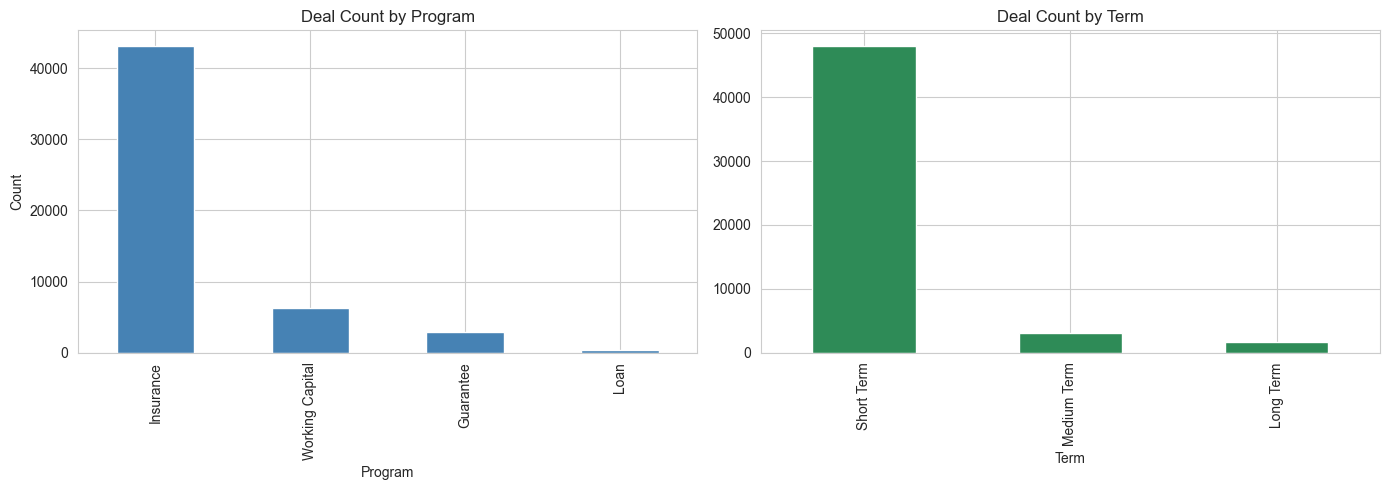

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Program'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Deal Count by Program')
axes[0].set_ylabel('Count')

df['Term'].value_counts().plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Deal Count by Term')

plt.tight_layout()
plt.savefig('program_term_dist.png', dpi=100)
plt.show()


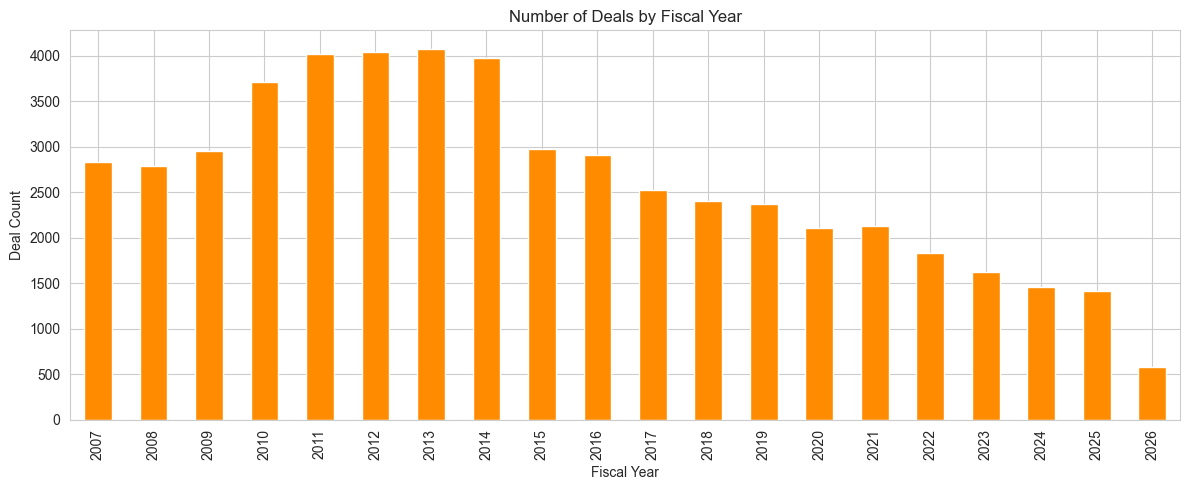

In [13]:
# Volume over time (Fiscal Year) - is the dataset growing/shrinking, any gaps?
fig, ax = plt.subplots(figsize=(12, 5))
df['Fiscal Year'].value_counts().sort_index().plot(kind='bar', ax=ax, color='darkorange')
ax.set_title('Number of Deals by Fiscal Year')
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Deal Count')
plt.tight_layout()
plt.savefig('deals_by_year.png', dpi=100)
plt.show()


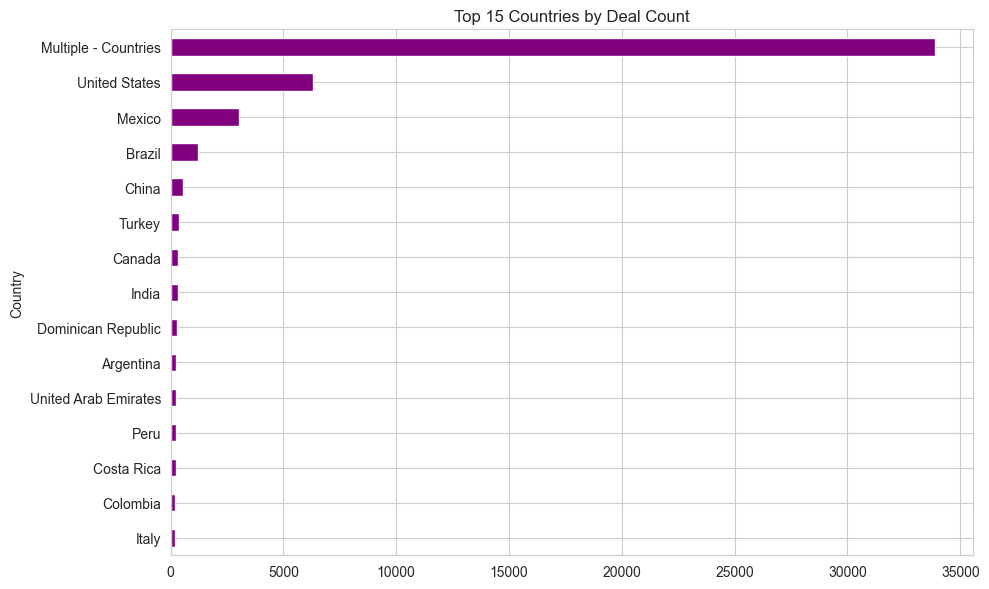

In [26]:
# Top 15 countries by deal count (note 'Multiple - Countries' dominates - a multi-country umbrella code)
top_countries = df['Country'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 6))
top_countries.sort_values().plot(kind='barh', ax=ax, color='purple')
ax.set_title('Top 15 Countries by Deal Count')
plt.tight_layout()
#plt.savefig('top_countries.png', dpi=100)
plt.show()


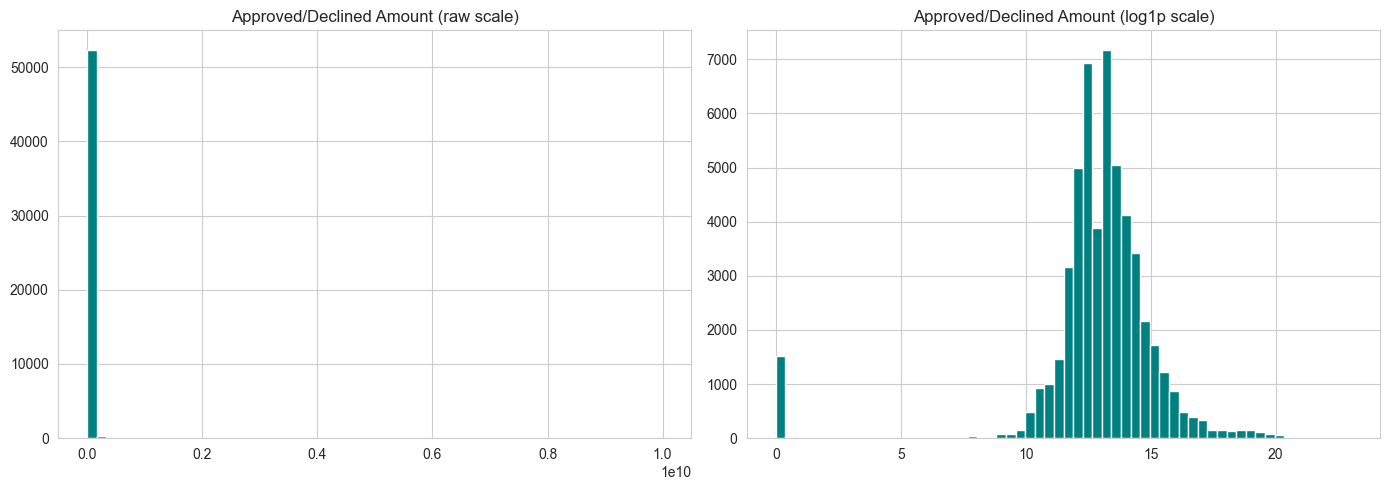

count    5.273400e+04
mean     5.440290e+06
std      7.139268e+07
min      0.000000e+00
25%      2.000000e+05
50%      5.000000e+05
75%      1.066257e+06
max      1.000000e+10
Name: Approved/Declined Amount, dtype: float64


In [31]:
# Approved/Declined Amount is heavily right-skewed (typical for financial transaction amounts)
# -> use log scale to actually see the distribution shape.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Approved/Declined Amount'], bins=60, color='teal')
axes[0].set_title('Approved/Declined Amount (raw scale)')

log_amt = np.log1p(df['Approved/Declined Amount'])
axes[1].hist(log_amt, bins=60, color='teal')
axes[1].set_title('Approved/Declined Amount (log1p scale)')

plt.tight_layout()
#plt.savefig('amount_distribution.png', dpi=100)
plt.show()

print(df['Approved/Declined Amount'].describe())


## 5. Bivariate / Relationship Analysis


In [16]:
# Median deal size by Program - Loan and Guarantee deals are typically much larger tickets
prog_amt = df.groupby('Program')['Approved/Declined Amount'].agg(['median', 'mean', 'count']).sort_values('median', ascending=False)
prog_amt


,median,mean,count
Program,,,
Loan,13142341.50,1.649945e+08,380
Working Capital,1800000.00,4.777859e+06,6241
Guarantee,1389982.53,3.984311e+07,2971
Insurance,400000.00,1.761574e+06,43142


C:\Users\Windows 11\AppData\Local\Temp\ipykernel_12864\3198238889.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Program', y=np.log1p(df['Approved/Declined Amount']), ax=ax,palette='flare')


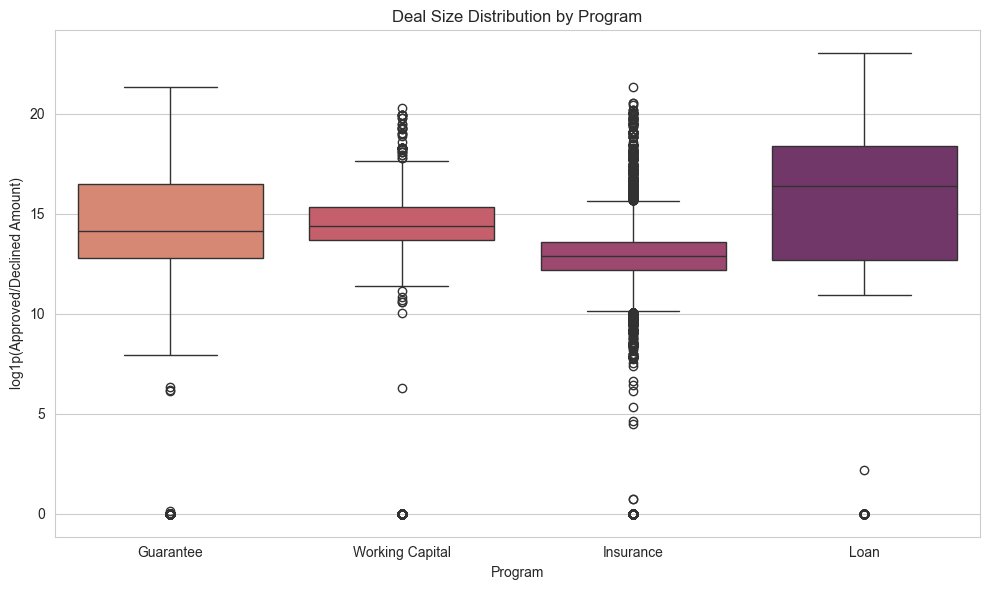

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
# log scale boxplot since amounts span many orders of magnitude
sns.boxplot(data=df, x='Program', y=np.log1p(df['Approved/Declined Amount']), ax=ax,palette='flare')
ax.set_ylabel('log1p(Approved/Declined Amount)')
ax.set_title('Deal Size Distribution by Program')
plt.tight_layout()
#plt.savefig('amount_by_program.png', dpi=100)
plt.show()


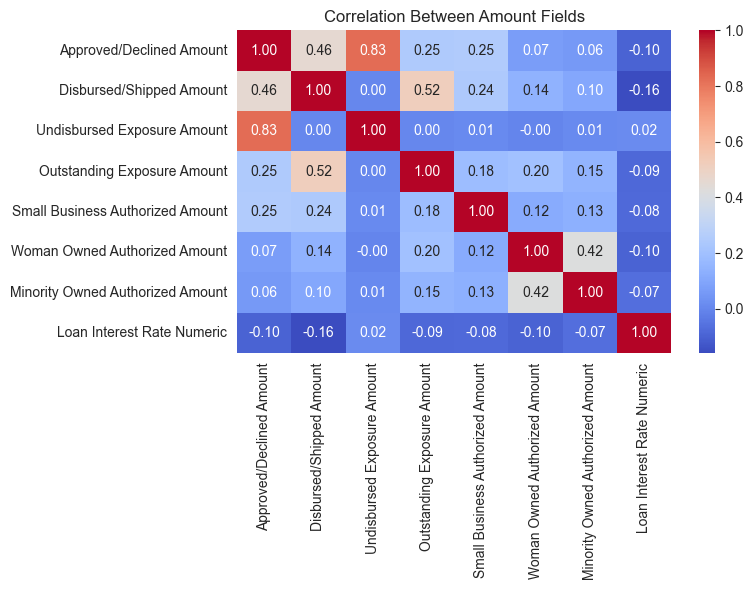

In [18]:
# Correlation among the numeric exposure/amount columns
num_cols = amount_cols + ['Loan Interest Rate Numeric']
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Between Amount Fields')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100)
plt.show()


In [19]:
# Decision outcome is almost entirely 'Approved' - check if Declined deals differ systematically
# (e.g. larger amounts, different program) - useful for the ML engineer deciding if this is even
# a viable classification target.
declined = df[df['Decision'] == 'Declined']
print("Declined deal count:", len(declined))
declined[['Fiscal Year','Program','Country','Approved/Declined Amount','Term']]


Declined deal count: 6


,Fiscal Year,Program,Country,Approved/Declined Amount,Term
20348,2012,Insurance,Mexico,13000000.0,Short Term
24424,2013,Guarantee,Vietnam,48465615.0,Long Term
28398,2014,Insurance,Lebanon,15000000.0,Short Term
31374,2015,Insurance,El Salvador,125000.0,Short Term
31375,2015,Insurance,Kenya,316846080.0,Short Term
49281,2023,Insurance,Benin,250000.0,Short Term


## 6. Outlier Detection

Financial amount columns are expected to be right-skewed with legitimate large outliers
(e.g. the Private Export Funding Corporation "Guarantee" deals worth hundreds of millions).
We flag statistical outliers but do NOT drop them — in this domain, a $1B guarantee is a real,
important deal, not a data-entry error. The ML engineer should decide per-model whether to cap/winsorize.


In [20]:
def iqr_outlier_bounds(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

low, high = iqr_outlier_bounds(df['Approved/Declined Amount'])
outlier_count = ((df['Approved/Declined Amount'] < low) | (df['Approved/Declined Amount'] > high)).sum()
print(f"IQR bounds: [{low:,.0f}, {high:,.0f}]")
print(f"Outliers by IQR rule: {outlier_count} ({outlier_count/len(df)*100:.1f}% of rows)")

# Zero-amount deals - are these legitimate (e.g. cancelled) or data issues?
zero_amt = df[df['Approved/Declined Amount'] == 0]
print("\nZero-amount deals:", len(zero_amt))
print(zero_amt['Deal Cancelled'].value_counts())


IQR bounds: [-1,099,385, 2,365,642]
Outliers by IQR rule: 7810 (14.8% of rows)

Zero-amount deals: 1517
Deal Cancelled
No     996
Yes    521
Name: count, dtype: int64


## 7. Feature Engineering for ML

Concrete, ready-to-use features derived from the raw columns. These are the columns an ML
engineer would actually want to feed into a model rather than the raw strings/dates.


In [21]:
# --- Date-derived features ---
df['Decision Year'] = df['Decision Date'].dt.year
df['Decision Month'] = df['Decision Date'].dt.month
df['Decision Quarter'] = df['Decision Date'].dt.quarter

# Loan tenor in days (Expiration - Effective), where both dates exist
df['Tenor Days'] = (df['Expiration Date'] - df['Effective Date']).dt.days

# --- Ratio / derived financial features ---
# Avoid divide-by-zero: use np.where guard
df['Disbursement Rate'] = np.where(
    df['Approved/Declined Amount'] > 0,
    df['Disbursed/Shipped Amount'] / df['Approved/Declined Amount'],
    np.nan
)
df['Exposure Remaining Pct'] = np.where(
    df['Approved/Declined Amount'] > 0,
    df['Outstanding Exposure Amount'] / df['Approved/Declined Amount'],
    np.nan
)

# --- Binary target candidates ---
df['Is Declined'] = (df['Decision'] == 'Declined').astype(int)      # severe class imbalance - see report
df['Is Cancelled'] = (df['Deal Cancelled'] == 'Yes').astype(int)
df['Is Small Business'] = (df['Small Business Authorized Amount'] > 0).astype(int)
df['Is Woman Owned'] = (df['Woman Owned Authorized Amount'] > 0).astype(int)
df['Is Minority Owned'] = (df['Minority Owned Authorized Amount'] > 0).astype(int)
df['Is Multi Country'] = (df['Country'] == 'Multiple - Countries').astype(int)

# --- High-cardinality categorical grouping ---
# Country has 190+ levels; for one-hot encoding, group rare countries into 'Other'
top_n_countries = df['Country'].value_counts().nlargest(20).index
df['Country Grouped'] = np.where(df['Country'].isin(top_n_countries), df['Country'], 'Other')

print(df[['Tenor Days','Disbursement Rate','Exposure Remaining Pct']].describe())
print()
print(df['Country Grouped'].value_counts())


         Tenor Days  Disbursement Rate  Exposure Remaining Pct
count  51479.000000       5.121700e+04            5.121700e+04
mean     361.449271       2.249869e+03            1.574090e+03
std      137.550801       5.089012e+05            3.562309e+05
min    -1714.000000       0.000000e+00            0.000000e+00
25%      365.000000       0.000000e+00            0.000000e+00
50%      365.000000       9.039186e-01            0.000000e+00
75%      366.000000       1.398222e+00            0.000000e+00
max     4366.000000       1.151703e+08            8.061923e+07

Country Grouped
Multiple - Countries    33887
United States            6304
Other                    4103
Mexico                   3030
Brazil                   1220
China                     545
Turkey                    378
Canada                    346
India                     317
Dominican Republic        302
Argentina                 256
United Arab Emirates      249
Peru                      245
Costa Rica                

In [22]:
# --- Recommended categorical encodings for the ML engineer ---
# Low-cardinality (good for one-hot): Program, Term, Policy Type, Decision Authority, Country Grouped
# High-cardinality (better for target/frequency encoding or embeddings):
#   Primary Applicant, Primary Lender, Primary Exporter, Primary Borrower, Product Description
for c in ['Program', 'Term', 'Policy Type', 'Decision Authority', 'Country',
          'Primary Applicant', 'Primary Lender', 'Primary Exporter', 'Primary Borrower']:
    print(f"{c}: {df[c].nunique()} unique values")


Program: 4 unique values
Term: 3 unique values
Policy Type: 24 unique values
Decision Authority: 3 unique values
Country: 153 unique values
Primary Applicant: 10628 unique values
Primary Lender: 1313 unique values
Primary Exporter: 11221 unique values
Primary Borrower: 8257 unique values


## 8. Export ML-Ready Dataset

Write out a cleaned, feature-engineered CSV plus a small data dictionary so the ML engineer
does not have to re-derive any of the steps above.


In [23]:
ml_ready_cols = [
    'Unique Identifier', 'Fiscal Year', 'Decision Year', 'Decision Month', 'Decision Quarter',
    'Decision', 'Is Declined', 'Deal Cancelled', 'Is Cancelled',
    'Country', 'Country Grouped', 'Is Multi Country',
    'Program', 'Policy Type', 'Decision Authority', 'Term', 'Tenor Days',
    'Brokered (bool)', 'Working Capital Delegated Authority (bool)',
    'Multiyear Working Capital Extension (bool)',
    'Approved/Declined Amount', 'Disbursed/Shipped Amount',
    'Undisbursed Exposure Amount', 'Outstanding Exposure Amount',
    'Disbursement Rate', 'Exposure Remaining Pct',
    'Small Business Authorized Amount', 'Is Small Business',
    'Woman Owned Authorized Amount', 'Is Woman Owned',
    'Minority Owned Authorized Amount', 'Is Minority Owned',
    'Loan Interest Rate Numeric', 'Loan Interest Rate Label',
]

ml_df = df[ml_ready_cols].copy()
ml_df.to_csv('ml_ready_dataset.csv', index=False)
print("Saved ml_ready_dataset.csv with shape:", ml_df.shape)
ml_df.head()


Saved ml_ready_dataset.csv with shape: (52734, 34)


,Unique Identifier,Fiscal Year,Decision Year,Decision Month,Decision Quarter,Decision,Is Declined,Deal Cancelled,Is Cancelled,Country,Country Grouped,Is Multi Country,Program,Policy Type,Decision Authority,Term,Tenor Days,Brokered (bool),Working Capital Delegated Authority (bool),Multiyear Working Capital Extension (bool),Approved/Declined Amount,Disbursed/Shipped Amount,Undisbursed Exposure Amount,Outstanding Exposure Amount,Disbursement Rate,Exposure Remaining Pct,Small Business Authorized Amount,Is Small Business,Woman Owned Authorized Amount,Is Woman Owned,Minority Owned Authorized Amount,Is Minority Owned,Loan Interest Rate Numeric,Loan Interest Rate Label
0,08003048XA0002,2007,2006,11,4,Approved,0,No,0,Private Export Funding Corp.,Other,0,Guarantee,NaN,Board,Long Term,NaN,False,NaN,NaN,24500000.0,24500000.0,0.0,0.0,1.0,0.0,0.0,0,0.0,0,0.0,0,NaN,NaN
1,08003048XA0003,2007,2006,11,4,Approved,0,No,0,Private Export Funding Corp.,Other,0,Guarantee,NaN,Board,Long Term,3669.0,False,NaN,NaN,50000000.0,50000000.0,0.0,0.0,1.0,0.0,0.0,0,0.0,0,0.0,0,NaN,NaN
2,08003048XA0004,2007,2007,8,3,Approved,0,No,0,Private Export Funding Corp.,Other,0,Guarantee,NaN,Board,Long Term,3683.0,False,NaN,NaN,136250000.0,136250000.0,0.0,0.0,1.0,0.0,0.0,0,0.0,0,0.0,0,NaN,NaN
3,08064737XM0001,2007,2007,9,3,Approved,0,No,0,United States,United States,0,Working Capital,NaN,Individual Delegated Authority,Short Term,314.0,False,True,NaN,2700000.0,2700000.0,0.0,0.0,1.0,0.0,2700000.0,1,0.0,0,2700000.0,1,NaN,NaN
4,08069888XG0003,2007,2006,11,4,Approved,0,No,0,United States,United States,0,Working Capital,NaN,Individual Delegated Authority,Short Term,38.0,False,True,NaN,233307.9,233307.9,0.0,0.0,1.0,0.0,0.0,0,0.0,0,0.0,0,NaN,NaN


In [24]:
# Simple data dictionary for the handoff
data_dictionary = pd.DataFrame({
    'column': ml_ready_cols,
    'dtype': [str(ml_df[c].dtype) for c in ml_ready_cols],
    'pct_missing': [round(ml_df[c].isnull().mean()*100, 2) for c in ml_ready_cols],
})
data_dictionary.to_csv('ml_ready_data_dictionary.csv', index=False)
data_dictionary


,column,dtype,pct_missing
0,Unique Identifier,object,0.00
1,Fiscal Year,int64,0.00
2,Decision Year,int32,0.00
3,Decision Month,int32,0.00
4,Decision Quarter,int32,0.00
5,Decision,object,0.00
6,Is Declined,int64,0.00
7,Deal Cancelled,object,0.00
8,Is Cancelled,int64,0.00
9,Country,object,0.00


## 9. Final Conclusions

See `analysis_report.txt` for the full write-up. Summary of the most important points for the
ML engineer:

1. **52,734 rows / 34 raw columns**, one row per EXIM deal, spanning Fiscal Year 2007–2026 (Q2).
   `Unique Identifier` is a verified primary key (no duplicates).
2. **`Decision` is extremely imbalanced** (52,728 Approved vs. 6 Declined = 99.99% / 0.01%) —
   not viable as a standard classification target without major re-framing (e.g. anomaly detection,
   or dropping this idea in favor of a different target).
3. **Better ML target candidates**: `Outstanding Exposure Amount` / `Disbursement Rate` (regression,
   useful for exposure/risk forecasting), or `Is Cancelled` (also imbalanced — ~1.6% — but far more
   balanced than Decision and more business-relevant).
4. **Missingness is structural, not random** — e.g. `Working Capital Delegated Authority` is only
   populated for Working Capital deals; `Policy Type` is only used for Insurance deals. Treat NaN
   as "not applicable" rather than imputing blindly.
5. **`"N/A"` was a literal string**, not a null, in the raw file — already converted to real NaN
   in this notebook.
6. **Country field is dominated by `"Multiple - Countries"`** (64% of rows) — a program-level
   umbrella code, not a real country. This needs to be handled explicitly (e.g. its own category)
   rather than treated as one of ~190 country levels.
7. **Amount columns are heavily right-skewed** — apply `log1p` transforms before feeding into
   linear/distance-based models; tree-based models (XGBoost/LightGBM) can typically handle the raw
   skew directly.
8. **High-cardinality text columns** (`Primary Applicant`, `Primary Lender`, `Primary Exporter`,
   `Primary Borrower`, `Product Description`) are not suitable for naive one-hot encoding — use
   frequency/target encoding, hashing, or drop for a first-pass model.
9. A cleaned, feature-engineered CSV (`ml_ready_dataset.csv`) and its data dictionary
   (`ml_ready_data_dictionary.csv`) have been exported for direct use in model training.
